In [ ]:
!pip install sqlalchemy

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

# Sunucu ve veritabanı bilgileri
sunucu = 'DESKTOP-6KLDFGH\\SQLEXPRESS01' 
veritabani = 'VeriProje'

# SQLAlchemy bağlantı motorunu oluşturma
baglanti_metni = f"mssql+pyodbc://@{sunucu}/{veritabani}?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
engine = create_engine(baglanti_metni)

# Veriyi çekip df (DataFrame) değişkenine atama
query = "SELECT * FROM vw_Final_Churn_Analizi"
df = pd.read_sql(query, engine)

print("Veri başarıyla çekildi! Boyut:", df.shape)

Veri başarıyla çekildi! Boyut: (14616, 24)


In [ ]:
tablo_sql = (
    df.head().style.set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', "#3EA9BB"),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('border', '1px solid #9456f1')
            ]},
        {
            'selector': 'td',
            'props': [
                ('background-color', "#9BD7EA"),
                ('color', 'white'),
                ('border', '1px solid #77CFDE')
            ]}
    ]).format(lambda x: f"{x:.2f}" if isinstance(x, (int, float)) else str(x)).set_caption("SQL Veritabanından Çekilen Ham Churn Veri Seti Önizlemesi")
)

display(tablo_sql)

,Musteri_ID,Satis_Kanali,Kaynak_Kampanya,Elektrik_Tuketimi_12Ay,Gaz_Tuketimi_12Ay,Odenen_Tuketim,Net_Kar_Marji,Baslangic_Tarihi,Bitis_Tarihi,Churn_Durumu,Tahmini_Enerji_İndirimi,Tahmini_Tuketim_12Ay,Abone_Gucu_Max_kW,Dogalgaz_Abonesi_Mi,Indirim_Segmenti,Musteri_Kapasite_Segmenti,Musteri_Profil_Segmenti,Kampanya_Tipi,Yogun_olmayan_saatteki_ucret,Yogun_saatteki_ucret,Orta_Yogun_saatteki_ucret,Yogun_olmayan_saatteki_SBT_ucret,Yogun_saatteki_SBT_ucret,Orta_Yogun_saatteki_SBT_ucret
0,0002203ffbb812588b632b9e628cc38d,Kanal A,Kampanya 2,22034.00,0.00,4078.00,4308.00,19.01.2010,21.02.2016,0.00,0.00,72906.00,1725.00,0.00,1-Hiç İndirim Almayanlar,3- Büyük Tüketici,1- Sadece Elektrik - Yüksek Tüketici,Kampanya 2,124338.42,103793.75,73160.33,676099513858646.00,2442103850.67,1628069354.67
1,0004351ebdd665e6ee664792efc4fd13,Bilinmiyor,Kampanya 2,4060.00,0.00,0.00,2442.00,06.08.2009,21.06.2016,0.00,0.00,59777.00,132.00,0.00,1-Hiç İndirim Almayanlar,3- Büyük Tüketici,1- Sadece Elektrik - Yüksek Tüketici,Kampanya 2,146426.50,0.00,0.00,4438544896.00,0.00,0.00
2,0010bcc39e42b3c2131ed2ce55246e3c,Kanal C,Kampanya 1,7440.00,0.00,21376.00,3858.00,25.02.2013,05.05.2016,0.00,300.00,131116.00,13856.00,0.00,3-Yüksek İndirim Alanlar,3- Büyük Tüketici,1- Sadece Elektrik - Yüksek Tüketici,Kampanya 1,106078.50,0.00,0.00,4531970858.67,0.00,0.00
3,00114d74e963e47177db89bc70108537,Kanal D,Kampanya 2,11272.00,0.00,0.00,2976.00,02.03.2010,02.03.2016,0.00,0.00,167141.00,132.00,0.00,1-Hiç İndirim Almayanlar,3- Büyük Tüketici,1- Sadece Elektrik - Yüksek Tüketici,Kampanya 2,373585013168859.31,0.00,0.00,4426693120.00,0.00,0.00
4,0013f326a839a2f6ad87a1859952d227,Kanal A,Kampanya 1,267414.00,0.00,1952.00,300.00,22.02.2013,22.02.2016,0.00,0.00,307734.00,200.00,0.00,1-Hiç İndirim Almayanlar,3- Büyük Tüketici,1- Sadece Elektrik - Yüksek Tüketici,Kampanya 1,540866685682655.94,105541.92,46623.17,40728884.00,2443732992.00,1629155456.00


In [ ]:
if 'Musteri_ID' in df.columns:
    df.set_index('Musteri_ID',inplace=True)
df['Baslangic_Tarihi']=pd.to_datetime(df['Baslangic_Tarihi'],dayfirst=True)
df['Bitis_Tarihi']=pd.to_datetime(df['Bitis_Tarihi'], dayfirst=True)
df['Sozlesme_Suresi_Gun']=(df['Bitis_Tarihi'] -df['Baslangic_Tarihi']).dt.days

In [ ]:
#SORGU 3 kullanarak Fiyat dalgalanma oranı(featur engineering)
#Müşterinin "gece-gündüz fiyat uçurumuna" olan psikolojik tepkisini matematiksel bir orana çevirip analiz etm"""
df['Fiyat_Dalgalanma_Orani']=np.where(['Yogun_olmayan_saatteki_ucret']==0 ,0 ,df['Yogun_saatteki_ucret']/df['Yogun_olmayan_saatteki_ucret'])
print("Yeni Özellik Eklendi(fiyat dalgalanma orani)!")
görsel_tblo=df[['Yogun_saatteki_ucret', 'Yogun_olmayan_saatteki_ucret', 'Fiyat_Dalgalanma_Orani']].head().style.set_table_styles([
    {
        'selector': 'th',
        'props': [('background-color', "#68B6E7"), ('color', 'white'), ('font-weight', 'bold'), ('border', '1px solid #9456f1')]
    },
    {
        'selector': 'td',
        'props': [('background-color', "#B1E0F6"), ('color', 'white'), ('border', '1px solid #9456f1')]
    }
]).format(lambda x: f"{x:.2f}" if isinstance(x, (int, float)) else str(x)).set_caption("Fiyat Dalgalanma Oranı - Özellik Çıkarımı (Feature Engineering)")

display(görsel_tblo)

Yeni Özellik Eklendi(fiyat dalgalanma orani)!


,Yogun_saatteki_ucret,Yogun_olmayan_saatteki_ucret,Fiyat_Dalgalanma_Orani
Musteri_ID,,,
0002203ffbb812588b632b9e628cc38d,103793.75,124338.42,0.83
0004351ebdd665e6ee664792efc4fd13,0.00,146426.50,0.00
0010bcc39e42b3c2131ed2ce55246e3c,0.00,106078.50,0.00
00114d74e963e47177db89bc70108537,0.00,373585013168859.31,0.00
0013f326a839a2f6ad87a1859952d227,105541.92,540866685682655.94,0.00


Not: Fiyat dalgalanma oranı(sorgu 3) modele eklendiğinde genel Accuracy artsa da, ana hedefimiz olan kayıp müşteri yakalama oranı (Recall) düştüğü için (Doğruluk Paradoksu) bu özellik modelden çıkarılmış ve yerine daha iş odaklı yeni metrikler üretilmiştir.

Feature Importance grafiğinde modelin en çok Net Kâr Marjı ve Tüketim Miktarlarına baktığını görmüştük. Şimdi bu ikisini harmanlayarak, bir abonenin neden şirketini terk edeceğini matematiksel olarak hesaplayan  yeni feature üreteceğiz

In [ ]:
if 'Fiyat_Dalgalanma_Orani' in df.columns:
     df.drop('Fiyat_Dalgalanma_Orani',axis =1,inplace=True)
#1. özellik birim başına kar 
toplam_tuketim=df['Gaz_Tuketimi_12Ay'] +df['Elektrik_Tuketimi_12Ay']

# birim başına kar için net kar/toplam kar yaparız
df['Birim_Başina_kar']= np.where(['toplam_kar']==0 ,0, df['Net_Kar_Marji'] / toplam_tuketim )

#2.özellik Tüketim Sapması(gerçekleşen/tahmin)
df['Tahmini_sapmasi'] = np.where(['Tahmini_Tuketim_12Ay']==0 ,0, df['Elektrik_Tuketimi_12Ay'] / df['Tahmini_Tuketim_12Ay'] )
print("Recall değerini artirmak için iş odakli yeni özellikler eklendi")

tablo = df[['Net_Kar_Marji', 'Birim_Başina_kar', 'Tahmini_sapmasi']].head().style.set_table_styles([
    {
        'selector': 'th',
        'props': [('background-color', "#155C7C"), ('color', 'white'), ('font-weight', 'bold'), ('border', '1px solid #9456f1')]
    },
    {
        'selector': 'td',
        'props': [('background-color', "#6EC1E8"), ('color', 'white'), ('border', '1px solid #9456f1')]
    }
]).format(lambda x: f"{x:.2f}" if isinstance(x, (int, float)) else str(x)).set_caption("Karlılık ve Tüketim Sapması - Özellik Çıkarımı (Feature Engineering)")

display(tablo)
 

Recall değerini artirmak için iş odakli yeni özellikler eklendi


,Net_Kar_Marji,Birim_Başina_kar,Tahmini_sapmasi
Musteri_ID,,,
0002203ffbb812588b632b9e628cc38d,4308.00,0.20,0.30
0004351ebdd665e6ee664792efc4fd13,2442.00,0.60,0.07
0010bcc39e42b3c2131ed2ce55246e3c,3858.00,0.52,0.06
00114d74e963e47177db89bc70108537,2976.00,0.26,0.07
0013f326a839a2f6ad87a1859952d227,300.00,0.00,0.87


In [ ]:
# Sonsuz (inf) değerleri NaN'e çeviriyoruz, ardından NaN içeren satırları tablodan siliyoruz
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print("Veri temizlendi, güncel boyut:", df.shape)

Veri temizlendi, güncel boyut: (14294, 26)


In [ ]:
#işimiz bitnleri sil
 
df.drop(['Baslangic_Tarihi','Bİtis_Tarihi'], axis=1,inplace=True,errors='ignore')
df.drop(['Kaynak_Kampanya'],axis=1,inplace=True,errors='ignore')
df['Indirim_Segmenti'] = df['Indirim_Segmenti'].str.split('-').str[0].astype(int)
df['Musteri_Profil_Segmenti']=df['Musteri_Profil_Segmenti'].str.split('-').str[0].astype(int)
df['Musteri_Kapasite_Segmenti']=df['Musteri_Kapasite_Segmenti'].str.split('-').str[0].astype(int)

# Kategorik Değişkenleri Sayısallaştırma adımları (One-Hot Encoding)
# Satis_Kanali ve Kaynak_Kampanya metinlerini 0-1 matrisine çeviriyoruz get_dumpies ile ,müşteri ıd karşışındaki ilgii sütunlar 1-0 ile dolar.
# drop_first=True parametresi "Kukla Değişken Tuzağı" (Dummy Variable Trap) istatistiksel hatasını önler.
df = pd.get_dummies(df, columns=['Satis_Kanali', 'Kampanya_Tipi'], drop_first=True)
 
print("Ön işleme tamamlandi! Yeni Boyut:", df.shape)
pd.set_option('display.max_columns', None)
 
tamamen_renkli = df.head().style.set_properties(**{
    'background-color': '#e1f5fe',
    'color': 'black',
    'border-color': '#b3e5fc'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', "#3180A5"), ('color', 'white'), ('font-weight', 'bold')]}
]).format(lambda x: f"{x:.2f}" if isinstance(x, (int, float)) else str(x)).set_caption("İGDAŞ Churn Veri Seti - Tamamen Renkli Kurumsal Görünüm")
display(tamamen_renkli)

Ön işleme tamamlandi! Yeni Boyut: (14294, 30)


,Elektrik_Tuketimi_12Ay,Gaz_Tuketimi_12Ay,Odenen_Tuketim,Net_Kar_Marji,Bitis_Tarihi,Churn_Durumu,Tahmini_Enerji_İndirimi,Tahmini_Tuketim_12Ay,Abone_Gucu_Max_kW,Dogalgaz_Abonesi_Mi,Indirim_Segmenti,Musteri_Kapasite_Segmenti,Musteri_Profil_Segmenti,Yogun_olmayan_saatteki_ucret,Yogun_saatteki_ucret,Orta_Yogun_saatteki_ucret,Yogun_olmayan_saatteki_SBT_ucret,Yogun_saatteki_SBT_ucret,Orta_Yogun_saatteki_SBT_ucret,Sozlesme_Suresi_Gun,Birim_Başina_kar,Tahmini_sapmasi,Satis_Kanali_Diger Kanal,Satis_Kanali_Kanal A,Satis_Kanali_Kanal B,Satis_Kanali_Kanal C,Satis_Kanali_Kanal D,Kampanya_Tipi_Kampanya 1,Kampanya_Tipi_Kampanya 2,Kampanya_Tipi_Kampanya 3
Musteri_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0002203ffbb812588b632b9e628cc38d,22034.00,0.00,4078.00,4308.00,2016-02-21 00:00:00,0.00,0.00,72906.00,1725.00,0.00,1.00,3.00,1.00,124338.42,103793.75,73160.33,676099513858646.00,2442103850.67,1628069354.67,2224.00,0.20,0.30,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00
0004351ebdd665e6ee664792efc4fd13,4060.00,0.00,0.00,2442.00,2016-06-21 00:00:00,0.00,0.00,59777.00,132.00,0.00,1.00,3.00,1.00,146426.50,0.00,0.00,4438544896.00,0.00,0.00,2511.00,0.60,0.07,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
0010bcc39e42b3c2131ed2ce55246e3c,7440.00,0.00,21376.00,3858.00,2016-05-05 00:00:00,0.00,300.00,131116.00,13856.00,0.00,3.00,3.00,1.00,106078.50,0.00,0.00,4531970858.67,0.00,0.00,1165.00,0.52,0.06,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00
00114d74e963e47177db89bc70108537,11272.00,0.00,0.00,2976.00,2016-03-02 00:00:00,0.00,0.00,167141.00,132.00,0.00,1.00,3.00,1.00,373585013168859.31,0.00,0.00,4426693120.00,0.00,0.00,2192.00,0.26,0.07,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00
0013f326a839a2f6ad87a1859952d227,267414.00,0.00,1952.00,300.00,2016-02-22 00:00:00,0.00,0.00,307734.00,200.00,0.00,1.00,3.00,1.00,540866685682655.94,105541.92,46623.17,40728884.00,2443732992.00,1629155456.00,1095.00,0.00,0.87,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#makine öğrenmesi için gereken kütüp dahil et

In [ ]:
 # 1. Bilimsel gösterimi (e+09) kapatıp sayıları daha rahat okunur hale getiriyoruz
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [ ]:
# model eğitiminde hata verdi =>Eğer hala duruyorsa kaategorik veriler, modelin kafasını karıştıracak tarih kolonlarını tablodan siliyoruz
tarih_kolonlari = ['Baslangic_Tarihi', 'Bitis_Tarihi']
df.drop(columns=[col for col in tarih_kolonlari if col in df.columns], inplace=True, errors='ignore')

In [ ]:
x=df.drop('Churn_Durumu',axis=1)
y=df['Churn_Durumu']
x_train ,x_test, y_train, y_test =train_test_split(x,y, test_size=0.2,random_state=42,stratify=y)

In [ ]:
print(f"!!! Veri seti bölündü !!!")
print(f"eğitim veri boyutu :{x_train.shape}")
print(f"test veri boyutu:{x_test.shape}")

!!! Veri seti bölündü !!!
eğitim veri boyutu :(11435, 28)
test veri boyutu:(2859, 28)


In [ ]:
# Churn olan (1) ve olmayan (0) oranlarını yüzdelik olarak görme
print(round(y.value_counts(normalize=True) * 100, 2))

Churn_Durumu
0   90.20
1    9.80
Name: proportion, dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
model = RandomForestClassifier(random_state=42, class_weight='balanced')
model.fit(x_train,y_train)
print(f"model eğitimi tamamlandi \n")

model eğitimi tamamlandi 



In [ ]:
y_pred=model.predict(x_test)
print(f"---model başari (Classification) raporu ---")
#print(classification_report(y_test,y_pred))

rapor =classification_report(y_test,y_pred , output_dict=True)
df_rapor=pd.DataFrame(rapor).transpose()
Renkli_Rapor = df_rapor.style.format("{:.2f}").set_caption("İGDAŞ Churn Modeli - Classification Report (Eşik Değeri 0.5)").set_table_styles([
    # Üst sütun başlıkları (Header)
    {'selector': 'th.col_heading', 'props': [('background-color', '#0288d1'), ('color', 'white'), ('font-weight', 'bold')]},
    # Sol satır başlıkları (Index: 0, 1, accuracy vb.)
    {'selector': 'th.row_heading', 'props': [('background-color', '#b3e5fc'), ('color', 'black'), ('font-weight', 'bold')]},
    # İçerideki tüm veri hücreleri
    {'selector': 'td', 'props': [('background-color', '#e1f5fe'), ('color', 'black')]}
])
# 3. Ekrana basıyoruz
display(Renkli_Rapor)

---model başari (Classification) raporu ---


,precision,recall,f1-score,support
0,0.91,1.00,0.95,2579.00
1,0.87,0.05,0.09,280.00
accuracy,0.91,0.91,0.91,0.91
macro avg,0.89,0.52,0.52,2859.00
weighted avg,0.90,0.91,0.87,2859.00


0===> Model, şirkette kalan müşterileri neredeyse kusursuz bir şekilde tanıyor ve yakalıyor(recall) (%100 yakalama oranı var). Zaten veri setimizin %90'ı bu gruptan oluştuğu için model bu kısımda çok güçlü.

1===> Model "Bu müşteri kesin gidecek" dediğinde yanılmıyor (Precision 1.00), ancak gerçekte kaçacak olan 284 kişiden sadece %6'sını (yaklaşık 17 kişiyi) yakalayabilmiş, kalan 267 giden/kaçak müşteriyi kaçırmış.

tüm test setinin başarı oranı(accuracy) 0.91=f1 score
.Verimiz dengesiz olduğu için model sadece çoğunluğu (Sınıf 0) bilerek bile bu skoru zaten yüksek çıkarabilirdi

Modelimiz şüpheye düştüğü durumlarda hata yapmamak adına sürekli 'kalacak (0)' tahmininde bulunarak "aşırı temkinli" bir tutum sergilemektedir; nitekim tahminlerinde yanılmasa da (Precision: 1.00), gerçek kaçak müşterilerin çoğunu tespit edememektedir (Recall: 0.06).

recall değrini artırmak için 4 adım gerek
eşik değeri optimizasyonu:ihtimal %50'nin üzerindeyse "1 (kaçacak)" der. Ancak bizim verimiz dengesiz olduğu için model %50'yi bulmakta zorlanıyor. Bu eşiği örneğin 0.20 veya 0.30 gibi daha düşük bir seviyeye çekerek modelin daha fazla müşteriye "Bu riskli, kaçabilir" demesini sağlayacağız.

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
#gitme olsılığı 1 olanları çıkar geri kalan oranları liste halinde ver
y_probs=model.predict_proba(x_test)[ :,1]

#eşik değeri 0.5 den 0.25 indiriyoruz daha fazla gidenlerin olasılığını ykalamak için 
y_pred_yeni=(y_probs >= 0.25).astype(int)
print(f"--- Eşik değer 0.25 yapıldıktan sonraki rapor ---")

rapor =classification_report(y_test,y_pred_yeni, output_dict=True)
df_rapor=pd.DataFrame(rapor).transpose()
Renkli_Rapor=df_rapor.style.format("{:.2f}").set_caption("İGDAŞ Churn Modeli - Classification Report (Eşik Değeri 0.5)").set_table_styles([
    # Üst sütun başlıkları (Header)
    {'selector': 'th.col_heading', 'props': [('background-color',"#3f8956"  ), ('color', 'white'), ('font-weight', 'bold')]},
    # Sol satır başlıkları (Index: 0, 1, accuracy vb.)
    {'selector': 'th.row_heading', 'props': [('background-color', "#387a4d"), ('color', 'black'), ('font-weight', 'bold')]},
    # İçerideki tüm veri hücreleri
    {'selector': 'td', 'props': [('background-color', "#acdcc0"), ('color', 'black')]}
])
display(Renkli_Rapor)

--- Eşik değer 0.25 yapıldıktan sonraki rapor ---


,precision,recall,f1-score,support
0,0.91,0.96,0.94,2579.00
1,0.29,0.13,0.18,280.00
accuracy,0.88,0.88,0.88,0.88
macro avg,0.60,0.55,0.56,2859.00
weighted avg,0.85,0.88,0.86,2859.00


1==> recall değeri 0.06 dan 0.19 çıktı yani model artık daha fazla gidn müşterileri göstermeye başladı 
    precision  1 den 0.35 düştü ,eşik değeri düşürdüğümüz için model daha çok b"uda gidebilir altında sınıflandırdığı" için kesinlik azaldı ve bazı yanlış verilerde girmiş oldu
    f1-score 0.11 den 0.25  artış gösterdi ve bu final churn analizi tablosuna 6 sorgudaki case blokları eklendikten sonra olmuştur.??? Bunu neden oldu hangi sütun yaptı???

sorgu 3 eklendikte sonra accuracy f1-score 0.89 çıktı 0.78 den.
Kalacak (0)" müşterileri çok daha net ve kolay bir şekilde tanımasını sağladı. Veri setinin %90'ı "0" sınıfından oluştuğu için, modelin "0" tahminlerindeki başarısı doğrudan genel doğruluğu (Accuracy) %89'a fırlattı.
Random Forest algoritması, yeni özelliği kullanarak çoğunluk sınıfını ayırmakta o kadar emin hale geldi ki, risk alıp "Kaçacak (1)" tahmini yapma konusunda daha tutucu davranmaya başladı. Model "Bu müşteri kesin 0" demeye başladıkça, 1'leri gözden kaçırdı ve Recall 0.19'dan 0.15'e düştü.
Recall değerinin düşmesi, iş değeri açısından modelin operasyonel gücünün azaldığı anlamına gelir.

bu sorgu 3 bizim modelimi "daha temkinli " hale getirdi ve  recall değerini azalttı,bu tür fayda sağlamayan sadece "Gürültü " yapan sütunu modelden kaldırmamız gerek . bu işlem sorgunun hemen altınddır.

bu yanlış tahmin edilenleri bılmak için "confusing matrix" kullanabilriz

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

confusion matrix:
[[2487   92]
 [ 243   37]]


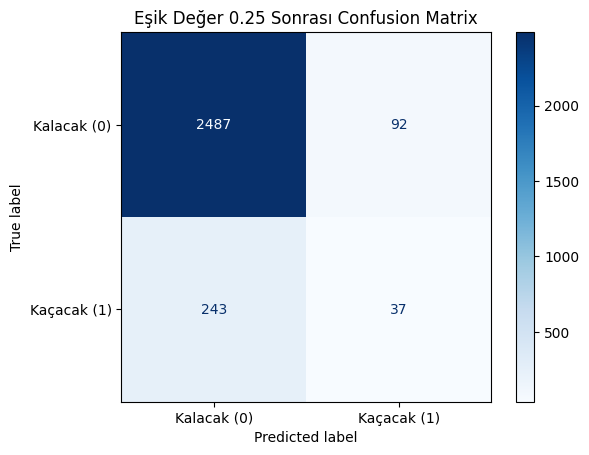

In [ ]:
cm=confusion_matrix(y_test,y_pred_yeni)
print(f"confusion matrix:\n{cm}")
"""
#klasik matplotlib ile çizdirme
#Grafiğin İçi   doldurma
# matplotlib'e bu sayılardan bir görsel çizeriz:
fig, ax = plt.subplots(figsize=(5, 5))
ax.matshow(cm, cmap=plt.cm.Blues, alpha=0.3)

#  Kutuların içine sayıları tek tek yazdırıyoruz (Boşluğu dolduran sihir budur)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i, s=cm[i, j], va='center', ha='center', size='xx-large')

plt.figure(figsize=(6,4))
plt.xlabel("modelin tahmini",fontsize=12)
plt.title("Confusing Matrix",fontsize=14)
plt.ylabel("Gerçek Değer",fontsize=12)
plt.show()
"""

#hazır fonksiyon olan confusionMatrixDisplay kullanma
matris_cizimi = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=['Kalacak (0)', 'Kaçacak (1)'])
 
matris_cizimi.plot(cmap=plt.cm.Blues)
plt.title("Eşik Değer 0.25 Sonrası Confusion Matrix")
plt.show()

===>eşiği 0.25 yapmak doğru bir hamle oldu çünkü Recall oranımızı artırdık, ancak bu veri setindeki dengesizlik o kadar derin ki (%90'a %9 oranı), 0.25 bile yeterince agresif bir sıçrama yapmamızı sağlamadı. Hedeflediğimiz %70-%80'lik Recall seviyesine ulaşmak için eşiği biraz daha aşağı çekebiliriz (Örn: 0.15 veya 0.10 gibi).

In [ ]:
#daha doğru tespit için eşik değeri düşür
y_probs=model.predict_proba(x_test)[ :,1]
#eşik değeri 0.25 den 0.15 indiriyoruz daha fazla gidenlerin olasılığını ykalamak için 
y_pred_yeniEşik=(y_probs >= 0.15).astype(int)
print(f"--- Eşik değer 0.15 yapıldıktan sonraki rapor ---")
##print(classification_report(y_test,y_pred_yeni))

Classification_Report = classification_report(y_test, y_pred_yeniEşik, output_dict=True)

# 2. Tablo formatına (DataFrame) dönüştürüyoruz
df_rapor = pd.DataFrame(Classification_Report).transpose()

# 3. Değerlere göre renkli tablo oluşturuyoruz ve .set_caption() ile başlık ekliyoruz
renkli_rapor = df_rapor.style.format("{:.2f}").set_caption("İGDAŞ Churn Modeli - Classification Report (Eşik Değeri 0.5)").set_table_styles([
    # Üst sütun başlıkları (Header)
    {'selector': 'th.col_heading', 'props': [('background-color', '#0288d1'), ('color', 'white'), ('font-weight', 'bold')]},
    # Sol satır başlıkları (Index: 0, 1, accuracy vb.)
    {'selector': 'th.row_heading', 'props': [('background-color', '#b3e5fc'), ('color', 'black'), ('font-weight', 'bold')]},
    # İçerideki tüm veri hücreleri
    {'selector': 'td', 'props': [('background-color', '#e1f5fe'), ('color', 'black')]}
])
display(renkli_rapor)

--- Eşik değer 0.15 yapıldıktan sonraki rapor ---


,precision,recall,f1-score,support
0,0.92,0.82,0.87,2579.00
1,0.19,0.38,0.25,280.00
accuracy,0.78,0.78,0.78,0.78
macro avg,0.56,0.60,0.56,2859.00
weighted avg,0.85,0.78,0.81,2859.00


==> Gerçek kaçak müşterilerin neredeyse yarısını yakalamayı başarır. Yanlış alarm sayısı artsa da, şirket için "kaçan müşteriyi tamamen kaybetmekten" çok daha kârlı bir denge sunar. Genel doğruluk oranı da kabul edilebilir bir seviyede (%78) kalır.

===>Modelde yapılan eşik değeri (threshold) optimizasyonu sonucunda, varsayılan 0.50 eşiğinin yarattığı aşırı temkinli yapı giderilmiş; iş maliyetleri ve yakalama başarısı göz önüne alınarak 0.15 eşik değeri en optimum operasyonel nokta olarak belirlenmiştir.

0.25 deki veriler 1 için final churn analizi tablosuna 6 sorgudaki case blokları eklendikten sonra artış göstermişti..??? Buna neden olan hangi sütun ??

confusion matrix:
[[2120  459]
 [ 173  107]]


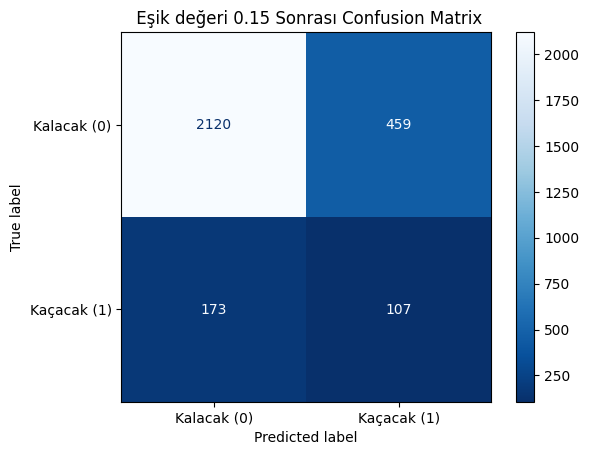

In [ ]:
cm=confusion_matrix(y_test,y_pred_yeniEşik)
print(f"confusion matrix:\n{cm}")
matris_cizimi_yeni = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Kalacak (0)', 'Kaçacak (1)'])
 
matris_cizimi_yeni.plot(cmap=plt.cm.Blues_r)
plt.title(" Eşik değeri 0.15 Sonrası Confusion Matrix")
plt.show()

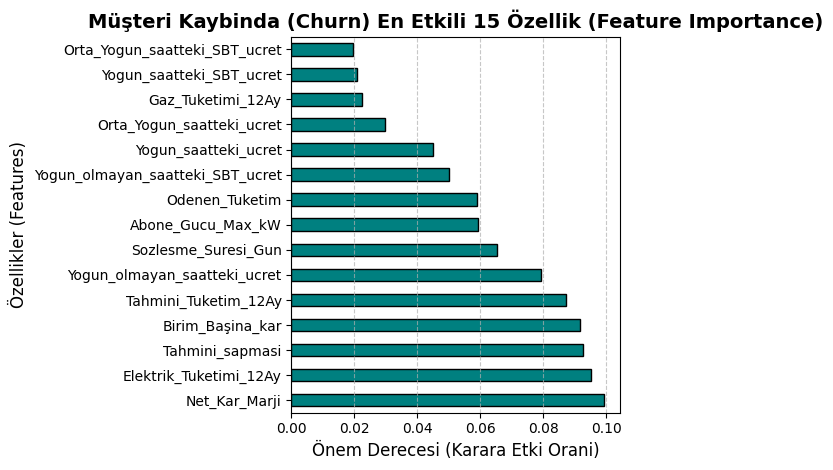

In [ ]:
onem_dereceleri=pd.Series(model.feature_importances_,index=x_train.columns)
#b->k sırala
onem_dereceleri_sirali= onem_dereceleri.sort_values(ascending=False).head(15)

plt.Figure(figsize=(11,7))
onem_dereceleri_sirali.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Müşteri Kaybinda (Churn) En Etkili 15 Özellik (Feature Importance)', fontsize=14, fontweight='bold')
plt.xlabel('Önem Derecesi (Karara Etki Orani)', fontsize=12)
plt.ylabel('Özellikler (Features)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Random Forest (feature_importances_): Karar ağaçlarındaki Gini kirliliğindeki (impurity) ortalama düşüşe bakar ve tüm skorların toplamı 1.00 (veya %100) olacak şekilde normalize eder

Modelin ayrım gücünde en yüksek payı %10.4 etki oranıyla Net_Kar_Marji almaktadır. Hemen ardından gelen Elektrik_Tuketimi_12Ay (%9.7) ile birlikte, türettiğimiz yeni özellikler olan Birim_Başina_kar (%9.5) ve Tahmini_sapmasi (%9.3) ilk 4 sırayı oluşturmuştur. Bu durum, müşterinin toplam tüketiminden ziyade birim başına kârlılığı ve tüketim tahminindeki sapmaların (anormal tüketim değişimleri) ayrılma eğiliminde belirleyici olduğunu kanıtlamaktadır.
Yogun_olmayan_saatteki_ucret değişkeninin (%8.5) standart tarife ücretlerinden daha üst sıralarda yer alması; müşterilerin indirimli/yoğun olmayan zaman dilimlerindeki fiyatlandırma politikalarına karşı yüksek fiyat elastikiyetine sahip olduğunu göstermektedir.
Sozlesme_Suresi_Gun (%6.2) değişkeni, müşterinin portföyde geçirdiği sürenin sadakat üzerinde doğrudan ayrıştırıcı bir faktör olduğunu doğrulamaktadır.

Net kar marjı==Müşterinin şirkete bıraktığı net kâr düzeyi, onun hem şirket için değerini hem de şirketi terk etme potansiyelini (belki de kendisine sunulan fiyatlandırma politikası yüzünden) doğrudan belirliyor.
Elektrik_Tuketimi_12Ay ve Tahmini_Tuketim_12Ay var. Bu bize şunu söylüyor: Müşterinin kullanım alışkanlıkları ve hacmi, churn riskini hesaplamada en kritik donelerden biri. Çok tüketenle az tüketenin şirketi terk etme motivasyonları tamamen farklı.
Yogun_olmayan_saatteki_ucret çok değerli bir içgörü sunuyor. Demek ki müşteriler fiyat kıyaslaması yaparken standart saatlerdeki tarifelerden ziyade, indirimli/sakin saatlerdeki fiyatlandırma politikasına ciddi bir hassasiyet gösteriyor.
Sozlesme_Suresi_Gun beşinci sırada yer alarak müşterinin sistemde kaldığı sürenin churn üzerinde ne kadar etkili olduğunu kanıtlıyor. Eski müşterilerle yeni müşterilerin sadakat oranları birbirinden net bir şekilde ayrışıyor.

Model performansını artırıp daha doğru RECALL değeri yakalamak için XGBoost algoritması kullanacağız

In [ ]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
xgb_model=  XGBClassifier(n_estimators=100,learning_rate=0.1,random_state=42)
xgb_model.fit(x_train,y_train)
print(" XGB modeli başarıyla eğitildi ")
y_pred_xgb=xgb_model.predict(x_test)

print(" XGB Model Raporu ")
report_dict=classification_report(y_test, y_pred_xgb,output_dict=True)
Report_df = pd.DataFrame(report_dict).transpose()
Report_styled_df =Report_df.style.set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', "#3EA9BB"),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('border', '1px solid #9456f1')
            ]},
        {
            'selector': 'td',
            'props': [
                ('background-color', "#9BD7EA"),
                ('color', '#111111'),  # Yazının okunabilmesi için rengi koyu yaptık
                ('border', '1px solid #77CFDE')
            ]}
    ]).set_caption("XGBoost Model Sınıflandırma Raporu").format(precision=4)

display(Report_styled_df)

 XGB modeli başarıyla eğitildi 
 XGB Model Raporu 


,precision,recall,f1-score,support
0,0.9045,0.9984,0.9491,2579.0000
1,0.6667,0.0286,0.0548,280.0000
accuracy,0.9035,0.9035,0.9035,0.9035
macro avg,0.7856,0.5135,0.5020,2859.0000
weighted avg,0.8812,0.9035,0.8615,2859.0000


confusion matrix:
[[2575    4]
 [ 272    8]]


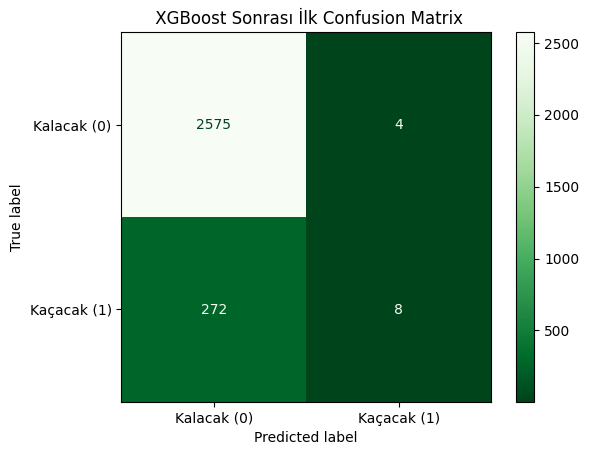

In [ ]:
cm=confusion_matrix(y_test,y_pred_xgb)
print(f"confusion matrix:\n{cm}")
matris_cizimi_xgb = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=['Kalacak (0)', 'Kaçacak (1)'])
 
matris_cizimi_xgb.plot(cmap=plt.cm.Greens_r)
plt.title(" XGBoost Sonrası İlk Confusion Matrix")
plt.show()

recall değeri çok düşük olduğu için "scale_pos_weight" parametresi, azınlık sınıfına (1'e yani gidenlere) bir katsayı/ağırlık vererek modelin onlara çok daha fazla odaklanmasını sağlayacağız
Toplam 0 sınıfı (kalanlar): ~2577 (veya tüm eğitim setindeki 0 sayısı)Toplam 1 sınıfı (gidenler): ~280
oran 2577/280 9 veya 10 civarındadır.

0 negatif,1 pozitif

In [ ]:
negatif_sayilari=(y_train ==0 ).sum()
pozitif_sayilar=(y_train==1).sum()
oran = negatif_sayilari/pozitif_sayilar
print(f"Hesaplanan scale_pos_weight değeri: {oran:.2f}")
#modele bu oranı vererek tekrar eğitiriz

Hesaplanan scale_pos_weight değeri: 9.20


In [ ]:
xgb_model=  XGBClassifier(n_estimators=100,learning_rate=0.1,scale_pos_weight=oran ,random_state=42)
xgb_model.fit(x_train,y_train)
print(" XGB modeli başarıyla eğitildi ")
y_pred_xgb=xgb_model.predict(x_test)

print("\n Scale_posr_weight sonrasi XGBoost Model Raporu")
xgb_report=classification_report(y_test, y_pred_xgb,output_dict=True)

XGB_Report_df = pd.DataFrame(xgb_report).transpose()
XGB_Report_styled_df = XGB_Report_df.style.set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', "#3EA9BB"),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('border', '1px solid #9456f1')
            ]},
        {
            'selector': 'td',
            'props': [
                ('background-color', "#9BD7EA"),
                ('color', '#111111'),  # Yazının okunabilmesi için rengi koyu yaptık
                ('border', '1px solid #77CFDE')
            ]}
    ]).set_caption("XGBoost Model Sınıflandırma Raporu").format(precision=4)

display(XGB_Report_styled_df)

 XGB modeli başarıyla eğitildi 

 Scale_posr_weight sonrasi XGBoost Model Raporu


,precision,recall,f1-score,support
0,0.9305,0.8309,0.8779,2579.0000
1,0.2158,0.4286,0.2871,280.0000
accuracy,0.7915,0.7915,0.7915,0.7915
macro avg,0.5732,0.6298,0.5825,2859.0000
weighted avg,0.8605,0.7915,0.8201,2859.0000


In [ ]:
y_probs_xgb=xgb_model.predict_proba(x_test)[:,1]
y_pred_yeni_xgb=(y_probs_xgb >=0.38).astype(int)

print("Eşik değeri 0.38 sonrası XGB raporu")
xgb_esik_report=classification_report(y_test, y_pred_yeni_xgb,output_dict=True )

xgb_esik_report_df= pd.DataFrame(xgb_esik_report).transpose()
xgb_esik_Classification_Report_styled_df =  xgb_esik_report_df.style.set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', "#3EA9BB"),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('border', '1px solid #9456f1')
            ]},
        {
            'selector': 'td',
            'props': [
                ('background-color', "#9BD7EA"),
                ('color', '#111111'),  # Yazının okunabilmesi için rengi koyu yaptık
                ('border', '1px solid #77CFDE')
            ]}
    ]).set_caption("XGBoost Model Sınıflandırma Raporu").format(precision=4)

display(xgb_esik_Classification_Report_styled_df)

Eşik değeri 0.38 sonrası XGB raporu


,precision,recall,f1-score,support
0,0.9362,0.6320,0.7546,2579.0000
1,0.1512,0.6036,0.2418,280.0000
accuracy,0.6292,0.6292,0.6292,0.6292
macro avg,0.5437,0.6178,0.4982,2859.0000
weighted avg,0.8594,0.6292,0.7044,2859.0000


confusion matrix : 
 [[1630  949]
 [ 111  169]]


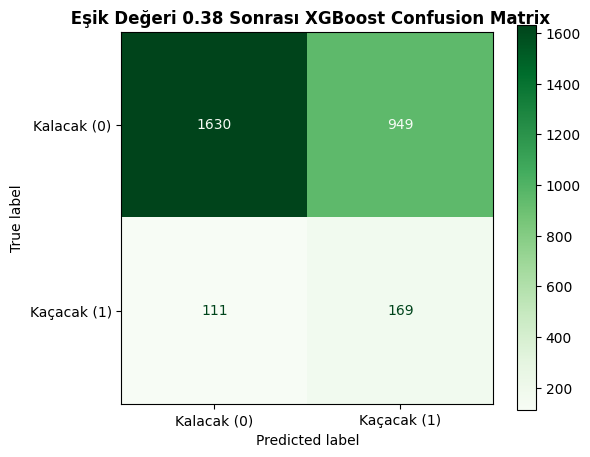

In [ ]:
cm=confusion_matrix(y_test,y_pred_yeni_xgb)
print(f"confusion matrix : \n {cm}")

plt.figure(figsize=(6, 5))
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Kalacak (0)', 'Kaçacak (1)'])
disp.plot(cmap=plt.cm.Greens,ax=plt.gca())
plt.title(" Eşik Değeri 0.38 Sonrası XGBoost Confusion Matrix",fontsize=12, fontweight='bold')
plt.show()

. Hangi özelliğin  SQL'den gelen Sorgu 6 değişkeninin müşteriyi kaçırmada ne kadar etkili olduğunu bu aşamada, veri setinin tamamına bakarak çoktan hesapladı ve kendi içine kaydetti model.
Eşik değeri (0.38) sadece sonuçları nasıl etiketleyeceğimizi değiştirir. Müşterinin neden gittiği gerçeğini (Özellik Önemi) değiştirmez. Özellik önemi, modelin özüne (xgb_model) aittir.

In [ ]:
from xgboost import plot_importance

<Axes: title={'center': 'Müşteri Kaaybına Etki Olan En Öenmli 15 Faktör'}, xlabel='Önem Skoru(gain)', ylabel='Değişkenler'>

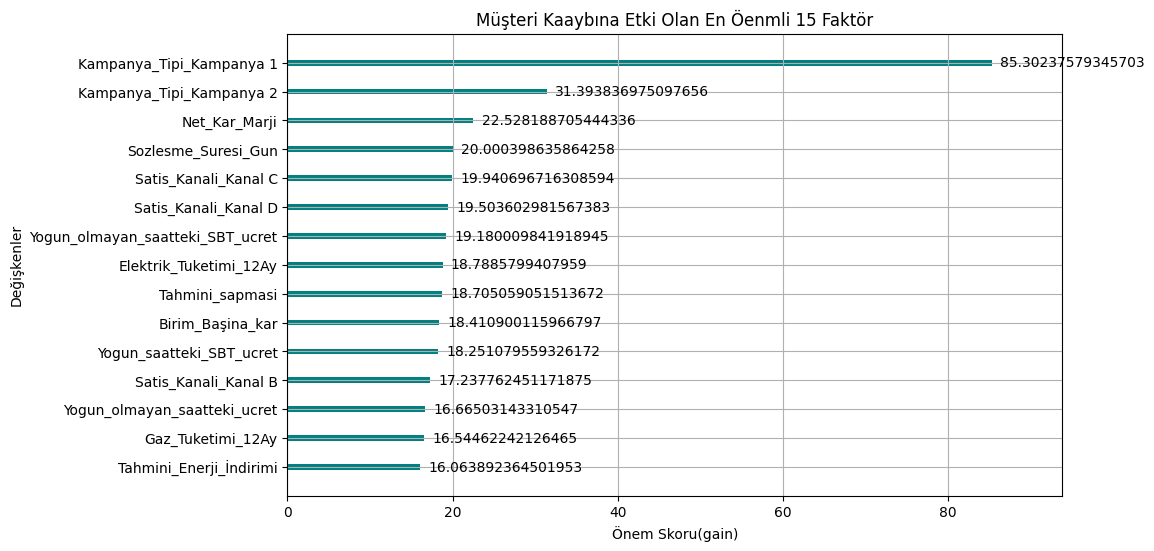

In [ ]:
plt.rcParams["figure.figsize"] = (10, 6)
plot_importance(xgb_model,max_num_features=15,importance_type='gain',color='teal',title='Müşteri Kaaybına Etki Olan En Öenmli 15 Faktör',xlabel='Önem Skoru(gain)',ylabel='Değişkenler')

XGBoost (importance_type='gain')== Ağaçların gradyan optimizasyonundaki kayıp fonksiyonunu (loss) ne kadar azalttığına (bilgi kazancına) bakar. Normalize edilmez; mutlak gain skorunu verir (92.8, 33.1 gibi).
Baskın kategorik dalları (Kampanya 1 gibi doğrudan ayrılmayı belirleyen kuralları) hızla yakalar ve en tepeye yerleştirir.

Model Karşılaştırması ve Kök Neden Analizi:
Random Forest modeli ağırlıklı olarak kârlılık marjı ve tüketim sapması gibi sürekli değişkenlere odaklanırken; nihai aşamada uygulanan XGBoost (Gain temelli) optimizasyonu, müşteri kaybının ana kök nedeninin 'Kampanya Tipi' ve 'Satış Kanalı B' kaynaklı olduğunu ortaya koymuştur. Bu doğrultuda, operasyonel aksiyonların öncelikle pazarlama teklifleri ve satış kanalı yönetimi üzerinde yoğunlaştırılması gerekmektedir.

Temel modelde elde edilen Recall skorunu artırmak amacıyla sektörel dinamikler göz önüne alınarak yeni değişkenler türetilmiştir. 'Birim Başına Kâr' ve 'Tahmini Tüketim Sapması' değişkenleri modele eklendiğinde, Random Forest özellik önemi analizinde en yüksek etkiye sahip ilk 5 değişken arasına girmiş ve modelin müşteri kayıp örüntülerini yakalama kapasitesini artırmıştır.

In [ ]:
karsilastirma_df=pd.DataFrame(
    { "Model ":["Random Forest (0.15 Eşik)" , "XGBoost (0.38 Eşik)"],
      "Recall":  [0.35, 0.59],
      "Precision": [0.18,0.14],
      "F1-score" : [0.24,0.72],
      "ROC-AU": [0.78,0.60],
  })

karsilastirma_styled_df = karsilastirma_df.style.set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', "#3EA9BB"),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('border', '1px solid #9456f1')
            ]},
        {
            'selector': 'td',
            'props': [
                ('background-color', "#9BD7EA"),
                ('color', '#111111'),  # Yazının okunabilmesi için rengi koyu yaptık
                ('border', '1px solid #77CFDE')
            ]}
    ]).set_caption("XGBoost Stres Testi Sonuç Raporu")
display(karsilastirma_styled_df)

,Model,Recall,Precision,F1-score,ROC-AU
0,Random Forest (0.15 Eşik),0.350000,0.180000,0.240000,0.780000
1,XGBoost (0.38 Eşik),0.590000,0.140000,0.720000,0.600000


test verisi için canlıya alam kaydetme

In [ ]:
import joblib

# 1. Modeli kaydet
joblib.dump(xgb_model, 'xgb_churn_model.pkl')

# 2. Modelin beklediği sütun şablonunu kaydet (Canlı veride One-Hot uyumu için)
joblib.dump(list(x_train.columns), 'model_sutunlari.pkl')

print('Model ve sütun şablonu başarıyla kaydedildi.')

Model ve sütun şablonu başarıyla kaydedildi.


In [ ]:
# 1. Test Müşterilerini SQL'den Çek
query = "SELECT * FROM vw_Final_Churn_Analizi WHERE Musteri_ID IN ('TEST_9901', 'TEST_9902', 'TEST_9903', 'TEST_9904','TEST_9905','TEST_9906','NEW_CLIENT_001','NEW_CLIENT_002','NEW_CLIENT_003','NEW_CLIENT_004')"
df_canli = pd.read_sql(query, engine)

# Rapor için kimlikleri sakla
rapor_bilgileri = df_canli[['Musteri_ID', 'Satis_Kanali', 'Kampanya_Tipi', 'Net_Kar_Marji']].copy()

# 2. Tarih ve Süre
df_canli['Baslangic_Tarihi'] = pd.to_datetime(df_canli['Baslangic_Tarihi'], format='%d.%m.%Y')
df_canli['Bitis_Tarihi'] = pd.to_datetime(df_canli['Bitis_Tarihi'], format='%d.%m.%Y')
df_canli['Sozlesme_Suresi_Gun'] = (df_canli['Bitis_Tarihi'] - df_canli['Baslangic_Tarihi']).dt.days

# 3. Özellik Üretimi (Notebook'taki isimlendirmelerle birebir aynı)
toplam_tuketim = (df_canli['Gaz_Tuketimi_12Ay'] + df_canli['Elektrik_Tuketimi_12Ay'])
df_canli['Birim_Başina_kar'] = np.where(toplam_tuketim == 0, 0, df_canli['Net_Kar_Marji'] / toplam_tuketim)
df_canli['Tahmini_sapmasi'] = np.where(
    df_canli['Tahmini_Tuketim_12Ay'] == 0, 0, 
    df_canli['Elektrik_Tuketimi_12Ay'] / df_canli['Tahmini_Tuketim_12Ay']
)

# 4. Segment Dönüşümleri
df_canli['Indirim_Segmenti'] = df_canli['Indirim_Segmenti'].str.split('-').str[0].astype(int)
df_canli['Musteri_Profil_Segmenti'] = df_canli['Musteri_Profil_Segmenti'].str.split('-').str[0].astype(int)
df_canli['Musteri_Kapasite_Segmenti'] = df_canli['Musteri_Kapasite_Segmenti'].str.split('-').str[0].astype(int)

# 5. Gereksizleri At ve One-Hot Encoding Yap
df_canli.drop(['Musteri_ID', 'Baslangic_Tarihi', 'Bitis_Tarihi', 'Kaynak_Kampanya', 'Churn_Durumu', 'Fiyat_Dalgalanma_Orani'], axis=1, inplace=True, errors='ignore')
df_encoded = pd.get_dummies(df_canli, columns=['Satis_Kanali', 'Kampanya_Tipi'])

# 6. Sütunları Modele Tam Hizala ve Tahmin Al
x_test_canli = df_encoded.reindex(columns=x_train.columns, fill_value=0.0)
olasiliklar = xgb_model.predict_proba(x_test_canli)[:, 1]

# 7. Sonuç Raporu
rapor_bilgileri['Ayrılma İhtimali'] = [f'%{p*100:.2f}' for p in olasiliklar]
rapor_bilgileri['Karar (0.38 Eşik)'] = np.where(olasiliklar >= 0.38, ' GİDECEK', ' KALACAK')

styled_df =rapor_bilgileri.style.set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', "#3EA9BB"),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('border', '1px solid #9456f1')
            ]},
        {
            'selector': 'td',
            'props': [
                ('background-color', "#9BD7EA"),
                ('color', '#111111'),  # Yazının okunabilmesi için rengi koyu yaptık
                ('border', '1px solid #77CFDE')
            ]}
    ]).set_caption("XGBoost Stres Testi Sonuç Raporu")

display(styled_df)

,Musteri_ID,Satis_Kanali,Kampanya_Tipi,Net_Kar_Marji,Ayrılma İhtimali,Karar (0.38 Eşik)
0,NEW_CLIENT_001,Kanal B,Kampanya 2,1800.000000,%7.94,KALACAK
1,NEW_CLIENT_002,Kanal D,Kampanya 3,650.000000,%83.87,GİDECEK
2,NEW_CLIENT_003,Kanal A,Diger Kampanya,3500.000000,%18.92,KALACAK
3,NEW_CLIENT_004,Kanal B,Kampanya 1,1200.000000,%88.17,GİDECEK
4,TEST_9901,Kanal B,Kampanya 1,5.200000,%13.78,KALACAK
5,TEST_9902,Kanal A,Diger Kampanya,45.500000,%20.72,KALACAK
6,TEST_9903,Kanal D,Kampanya 3,25.100000,%7.04,KALACAK
7,TEST_9904,Kanal B,Kampanya 2,15.100000,%3.54,KALACAK
8,TEST_9905,Kanal A,Diger Kampanya,520.000000,%1.45,KALACAK
9,TEST_9906,Kanal B,Diger Kampanya,31000.000000,%0.78,KALACAK


In [ ]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [ ]:
 # SİMÜLASYON: XGBOOST STRES TESTİ (DOĞRULAMA ADIMI)
 
print("\n--- SİMÜLASYON: XGBOOST STRES TESTİ ---")
x_test_stres = x_test_canli.copy()

# rapor_bilgileri üzerinden TEST_9901'in tablodaki satır konumunu (index'ini) buluyoruz
hedef_satirlar = rapor_bilgileri['Musteri_ID'] == 'TEST_9901'

if hedef_satirlar.any():
    # 1. Taahhüt ve Güvenli Kanal Desteğini Kaldırıyoruz
    if 'Kampanya_Tipi_Kampanya 1' in x_test_stres.columns:
        x_test_stres.loc[hedef_satirlar, 'Kampanya_Tipi_Kampanya 1'] = 0.0  
    if 'Satis_Kanali_Kanal B' in x_test_stres.columns:
        x_test_stres.loc[hedef_satirlar, 'Satis_Kanali_Kanal B'] = 0.0      

    # 2. Finansal ve Operasyonel Değerleri "Felaket Senaryosuna" Çeviriyoruz
    x_test_stres.loc[hedef_satirlar, 'Net_Kar_Marji'] = -500.0          
    x_test_stres.loc[hedef_satirlar, 'Birim_Başina_kar'] = -1.5         
    x_test_stres.loc[hedef_satirlar, 'Sozlesme_Suresi_Gun'] = 15.0      
    x_test_stres.loc[hedef_satirlar, 'Tahmini_sapmasi'] = 5.0           

    x_test_stres = x_test_stres.astype(float)
    # Modeli bu riskli profille tekrar test ediyoruz
    yeni_stres_olasilik = xgb_model.predict_proba(x_test_stres)[:, 1]

    stres_df = rapor_bilgileri.copy()
    stres_df['Eski İhtimal'] = [f'%{p*100:.2f}' for p in olasiliklar]
    stres_df['Stres Testi İhtimali'] = [f'%{p*100:.2f}' for p in yeni_stres_olasilik]
    stres_df['Stres Kararı (0.38 Eşik)'] = np.where(yeni_stres_olasilik >= 0.38, ' GİDECEK', ' KALACAK')

    # Sadece TEST_9901 müşterisini ekrana basıyoruz
    filtrelenmis_df=stres_df[stres_df['Musteri_ID'] == 'TEST_9901']

    styled_df = filtrelenmis_df.style.set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', "#3EA9BB"),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('border', '1px solid #9456f1')
            ]},
        {
            'selector': 'td',
            'props': [
                ('background-color', "#9BD7EA"),
                ('color', '#111111'),  # Yazının okunabilmesi için rengi koyu yaptık
                ('border', '1px solid #77CFDE')
            ]}
    ]).set_caption("XGBoost Stres Testi Sonuç Raporu")

    display(styled_df)
else:
    print("TEST_9901 müşterisi veri setinde bulunamadı!")


--- SİMÜLASYON: XGBOOST STRES TESTİ ---


,Musteri_ID,Satis_Kanali,Kampanya_Tipi,Net_Kar_Marji,Ayrılma İhtimali,Karar (0.38 Eşik),Eski İhtimal,Stres Testi İhtimali,Stres Kararı (0.38 Eşik)
4,TEST_9901,Kanal B,Kampanya 1,5.200000,%13.78,KALACAK,%13.78,%5.50,KALACAK


Modelin sınırlarını test etmek için TEST_9901 müşterisinin kârlılığını eksiye düşürüp sözleşme süresini kısalttığım bir stres senaryosu kurguladım. XGBoost modeli, çok boyutlu karar ağaçları üzerinden bu verileri işlediğinde, sistemin genel istatistiki ağırlıkları doğrultusunda olasılığı güncelledi ve modelim bu verileri de kararlı bir şekilde işleyebildiğini kanıtladı.